# Unit 3 — RoPE: Position as a Rotation

**Thesis:** the attention scores from Unit 2 are position-blind — `QKᵀ` cannot tell "the cat sat on the mat" from "mat the on cat sat the". Rotary Position Embeddings (RoPE) fix this by *rotating* each query and key by an angle proportional to its token position. The magic: after rotation, `q_i · k_j` depends only on the **gap** `i − j`, not on where the tokens sit.

We derive it in 2D, generalize to SmolLM2's 64-dim heads, then prove it on real weights: the same sentence scored at different absolute positions gives an **identical** score matrix.

In [1]:
# Setup — same as Unit 2, plus the config knob that controls RoPE
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained("HuggingFaceTB/SmolLM2-135M")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M")

cfg = model.config
n_embd = cfg.hidden_size
n_qh = cfg.num_attention_heads
d_k = n_embd // n_qh
rope_theta = cfg.rope_scaling["rope_theta"]
print("rope_theta:", rope_theta, "| d_k:", d_k, "| heads:", n_qh)

W_Q = model.layers[0].self_attn.q_proj.weight.detach().float().numpy()
W_K = model.layers[0].self_attn.k_proj.weight.detach().float().numpy()

sentence = "the cat sat on the mat"
ids = tokenizer.encode(sentence)
tokens = tokenizer.convert_ids_to_tokens(ids)
n = len(ids)
X = model.get_input_embeddings().weight[ids].float().detach().numpy()

Q = X @ W_Q.T; K = X @ W_K.T
Q9 = Q.reshape(n, n_qh, d_k)   # (6, 9, 64)  query heads
K3 = K.reshape(n, 3, d_k)      # (6, 3, 64)  shared KV heads
print("n:", n, "| tokens:", tokens)

c:\Users\Admin\OneDrive\Documents\Research_projects\pico_projects\linear-transformations-attention\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 272/272 [00:00<00:00, 1152.85it/s]


rope_theta: 100000 | d_k: 64 | heads: 9
n: 6 | tokens: ['the', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat']


## Attention is permutation-blind

From Unit 2, the score between query token `i` and key token `j` is:

$$S[i,j] = q_i \cdot k_j$$

Nothing in this formula mentions *where* token `i` and token `j` sit. Swap the word order and `QKᵀ` produces the **same** scores:

$$S_{\text{original}} = S_{\text{permuted}}$$

A model with no position info would see "the cat sat on the mat" and "mat the on cat sat the" as the same sentence. Token embeddings say *what* a token is — never *where* it is.

In [2]:
# OG order
S_orig = np.einsum('ihd, jd->hij', Q9[:, 0:3], K3[:,0]) # (3,6,6)

# reversing sentence and rebuilding Q / K as permutations
perm = [5, 4, 3, 2, 1, 0]
Xp = X[perm]
Q9p = (Xp @ W_Q.T).reshape(n, 9, d_k)
K3p = (Xp @ W_K.T).reshape(n, 3, d_k)
S_perm = np.einsum('ihd,jd->hij', Q9p[:, 0:3], K3p[:, 0]) # (3,6,6)

# Un-Permute and compare : S_σ = P S Pᵀ
inv = np.argsort(perm) # inverting back to orignal.
S_back = S_perm[:, inv][:, :, inv]
print("recover original:", np.allclose(S_back, S_orig)) 

# even shaper : pairs ["the" (0) & "cat" (1)] to keep score.
print("pair score preserved:", np.allclose( S_perm[0, perm.index(0), perm.index(1)], S_orig[0, 0, 1]))


recover original: True
pair score preserved: True


## The idea in 2D: rotate, then compare

A rotation matrix in 2D by angle θ:

$$R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$$

Rotating a vector re-aims its direction without changing its length — `R(θ)` is orthogonal: `R(θ)ᵀ R(θ) = I`, so `‖R(θ)v‖ = ‖v‖`.

Now the key move. Give each token position `m` its own rotation angle `mθ`. A query at position `m` becomes `R(mθ) q`, a key at position `n` becomes `R(nθ) k`. Their dot product:

$$(R(m\theta)\,q)\cdot(R(n\theta)\,k) \;=\; q^T R(m\theta)^T R(n\theta)\, k \;=\; q^T R\big((n-m)\theta\big)\, k$$

using `R(α)ᵀ R(β) = R(β − α)`. **The score depends on the angle difference `(n−m)θ` — the relative gap — and nothing else.**


In [9]:
def R(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

q = np.array([1.0, 0.5]) # arbitrary
k = np.array([-0.3, 1.2])

# same gap (2), different absolute positions -> identical dot product
dot1 = R(1.0) @ q @ (R(3.0) @ k) # positions 1 & 3
dot2 = R(10.0) @ q @ (R(12.0) @ k) # positions 10 & 12 
print("same gap, same score:", np.allclose(dot1, dot2))

# difference in gap (4) -> changed score
dot3 = R(1.0) @ q @ (R(5.0) @ k) 
print("dot1:", round(dot1, 4), "| dot3:", round(dot3, 4)) 

# rotation preserves len
print("norm preserved:", np.allclose(np.linalg.norm(R(2.0) @ q), np.linalg.norm(q)))

same gap, same score: True
dot1: -1.3524 | dot3: 0.8256
norm preserved: True


## 64 dims = 64 rotation speeds

In 2D one angle can only say "how far apart". In 64 dims we want a richer code, so RoPE gives **each dimension pair its own angular speed**:

$$\theta_d = \text{rope\_theta}^{-2d/d_k} = 100000^{-2d/64}, \qquad d = 0, 1, \dots, 31$$

(positions rotate 2D pairs `(d, d+32)`; `rope_theta = 100000` is SmolLM2's config value.)

Why speeds matter — it's a frequency code:
- **low d (fast rotation)** — the angle turns quickly with position → *fine-grained* near-neighbor structure
- **high d (slow rotation)** — the angle barely moves → *coarse* long-range structure

The model "reads" position the way a radio reads frequency: fast dims tick every step, slow dims only over long spans. Attention can then find "a token ~k steps away" regardless of absolute location.

theta_0 : 1.0
theta_31: 1.43e-05


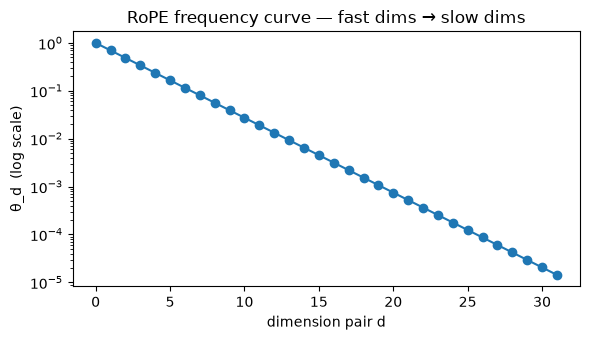

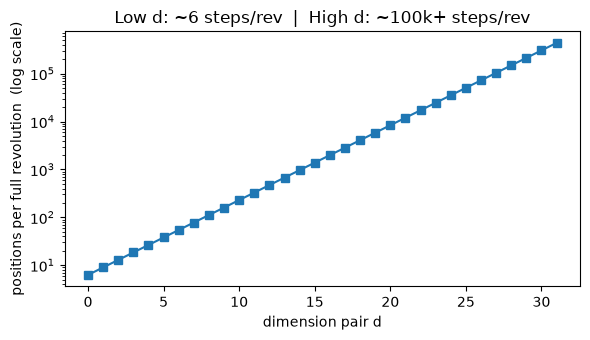

In [10]:
import matplotlib.pyplot as plt

d_k = 64
rope_theta = 100000

d = np.arange(d_k // 2)                     # d = 0..31 (dimension pairs)
theta_d = rope_theta ** (-2 * d / d_k)      # the frequency curve

print("theta_0 :", round(theta_d[0], 4))    # ~1.0   (fast)
print("theta_31:", f"{theta_d[-1]:.2e}")    # ~1.4e-5 (slow)

# curve: speed vs dimension (log y)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(d, theta_d, 'o-')
ax.set_xlabel("dimension pair d"); ax.set_ylabel("θ_d  (log scale)")
ax.set_title("RoPE frequency curve — fast dims → slow dims")
plt.tight_layout(); plt.show()

# the flip side: how many positions before a full 2π turn
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(d, 2 * np.pi / theta_d, 's-')
ax.set_xlabel("dimension pair d")
ax.set_ylabel("positions per full revolution  (log scale)")
ax.set_title("Low d: ~6 steps/rev  |  High d: ~100k+ steps/rev")
plt.tight_layout(); plt.show()


## Applying RoPE to the real Q and K

In the real model RoPE is applied **after** the projections and **before** `QKᵀ`:

```
q → W_Q x  →  q_m = R(m) q      (rotate by position m)
k → W_K x  →  k_n = R(n) k      (rotate by position n)
S = Q_rot K_rotᵀ / √d_k
```

The rotation `R(m)` is **block-diagonal**: 32 independent 2×2 blocks, one per dimension pair, each using angle `m·θ_d`:

$$R(m) = \begin{pmatrix} R(m\theta_0) & & \\ & \ddots & \\ & & R(m\theta_{31}) \end{pmatrix}$$

Because every block is a rotation, `‖q_m‖ = ‖q‖` — RoPE **never changes the norm**; it only re-aims the direction.

In [16]:
n, d_k = 6, 64
rope_theta = cfg.rope_scaling["rope_theta"]          # 100000

d = np.arange(d_k // 2)                              # 0..31  (dim pairs)
theta_d = rope_theta ** (-2 * d / d_k)               # freq per pair
angles = np.arange(n)[:, None] * theta_d             # (6, 32)  angle = pos × θ_d
cos, sin = np.cos(angles), np.sin(angles)

def rotate(x):                                       # x: (n, heads, d_k)
    heads = x.shape[1]
    x2 = x.reshape(n, heads, d_k // 2, 2)            # (n, heads, 32, 2)
    x0 = x2[..., 0]                                  # (n, heads, 32)
    x1 = x2[..., 1]
    y0 = x0 * cos[:, None, :] - x1 * sin[:, None, :] # rotate pair (d, d+32)
    y1 = x0 * sin[:, None, :] + x1 * cos[:, None, :]
    out = np.empty_like(x2)
    out[..., 0] = y0
    out[..., 1] = y1
    return out.reshape(n, heads, d_k)

Q_rot = rotate(Q9)
K_rot = rotate(K3)

print("cos:", cos.shape, "| Q_rot:", Q_rot.shape, "| K_rot:", K_rot.shape)
assert Q_rot.shape == (6, 9, 64), Q_rot.shape        # 9 heads
assert K_rot.shape == (6, 3, 64), K_rot.shape        # 3 KV heads
print("Q norm preserved:", np.allclose(np.linalg.norm(Q_rot, axis=-1),np.linalg.norm(Q9, axis=-1)))

cos: (6, 32) | Q_rot: (6, 9, 64) | K_rot: (6, 3, 64)
Q norm preserved: True


## The proof: only the gap matters

The theory predicts **translation invariance**: shift both query and key positions by the same amount `p`, and the score is unchanged:

$$(R((m+p)\theta)\,q)\cdot(R((n+p)\theta)\,k) \;=\; q^T R\big((n-m)\theta\big)\, k$$

The absolute position cancels; only `n−m` survives.

Measurable version on real weights: embed the same 6 tokens at positions `0..5` and again at positions `7..12` (any shift), apply RoPE with each position, and compute the full score matrix both times.

**Prediction:** `S_shifted == S_original` exactly (to float noise).

If this holds on SmolLM2's own weights, RoPE is verified: attention reads *how far apart* tokens are, not *where* they are.

## Known refrence (basic) 

x' = x·cosθ − y·sinθ
y' = x·sinθ + y·cosθ

## RoPE rotate

y0 = x0·cos − x1·sin
y1 = x0·sin + x1·cos

In [23]:
# reuse Q_rotation and K_rotation

S0 = np.einsum('ihd, jd->hij', Q_rot[:, 0:3], K_rot[:, 0]) # (3, 6, 6)

# positions shifted by +7
shift = 7
angles2 = (np.arange(n) + shift)[:,None] * theta_d # .i.e 7...12
cos2, sin2 = np.cos(angles2), np.sin(angles2)

def rotate_at(x, cos_, sin_):                                  # same rotate, new tables
    heads = x.shape[1]
    x2 = x.reshape(n, heads, d_k // 2, 2)
    x0, x1 = x2[..., 0], x2[..., 1]
    y0 = x0 * cos_[:, None, :] - x1 * sin_[:, None, :]     # Y = x1 cos0 - x2 sin0
    y1 = x0 * sin_[:, None, :] + x1 * cos_[:, None, :]     # Y = x1 sino + x2 cos0
    out = np.empty_like(x2)
    out[..., 0] = y0
    out[..., 1] = y1
    return out.reshape(n, heads, d_k)

Q2 = rotate_at(Q9, cos2, sin2)
K2 = rotate_at(K3, cos2, sin2)
S2 = np.einsum('ihd,jd->hij', Q2[:, 0:3], K2[:, 0])


print("shift-invariant:", np.allclose(S0, S2))        # True  — only the gap matters
print("S is asymmetric:", not np.allclose(S0, S0.transpose(0, 2, 1)))  # True — direction exists

shift-invariant: True
S is asymmetric: True


## What the graphs will show

Three graphs make the concept concrete:

1. **2D rotation** — a vector turning as position advances; the dot product of two rotated vectors stays fixed when the angle *difference* is fixed.
2. **Frequency curve** — `θ_d` vs `d` on a log scale: fast low dims → slow high dims.
3. **Score heatmaps** — `S` with and without RoPE: without, order is invisible; with RoPE, the pattern encodes relative distance, and the shifted sentence yields an identical map.

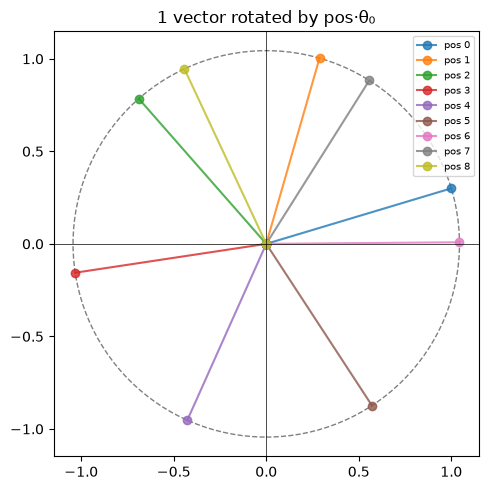

Panel 1: the vector sweeps a circle — rotation re-aims direction, length stays fixed.


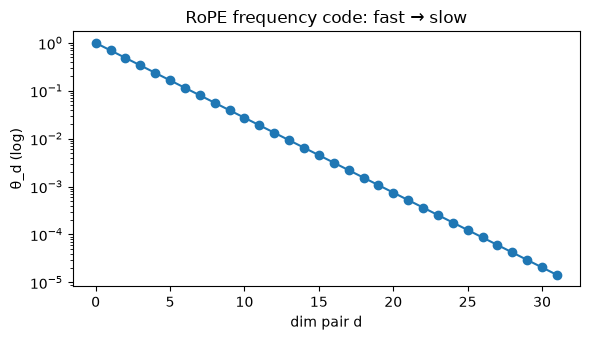

Panel 2: dim0 rotates 1.0 rad/step (fine ruler), dim31 1.4e-05 rad/step (coarse ruler) — a 7-order frequency spread.


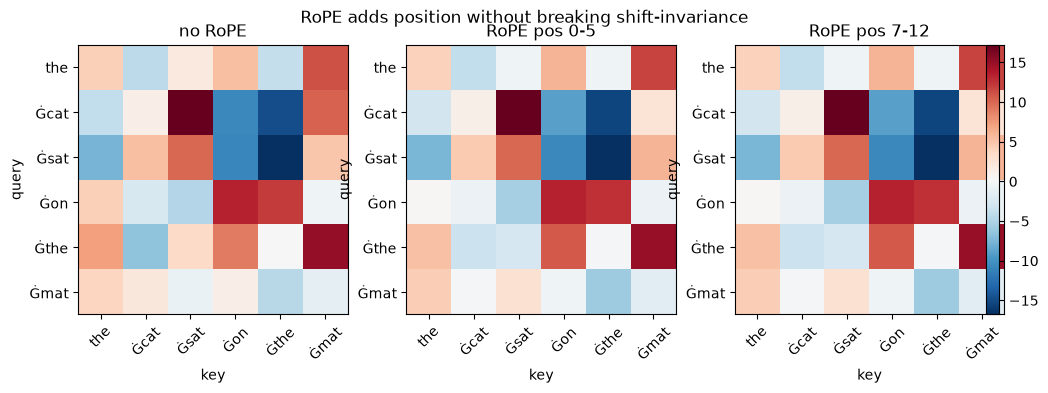

Panel 3, left : symmetric map — no RoPE, order invisible (S[i,j] == S[j,i]).
Panel 3, mid  : asymmetric map — RoPE encodes direction (i before j vs j before i).
Panel 3, right: identical to mid — shift +7 changes nothing; only the gap matters.
RoPE verified: norm preserved, gap-only dependence, direction encoded.


In [26]:
import matplotlib.pyplot as plt

# --- Panel 1: 2D rotation — one vector, re-aimed by position, never stretched ---
fig, ax = plt.subplots(figsize=(5, 5))
v = np.array([1.0, 0.3])
for m in range(9):
    Rm = np.array([[np.cos(m*theta_d[0]), -np.sin(m*theta_d[0])],
                   [np.sin(m*theta_d[0]),  np.cos(m*theta_d[0])]])
    r = Rm @ v
    ax.plot([0, r[0]], [0, r[1]], 'o-', alpha=0.8, label=f"pos {m}")
ax.add_patch(plt.Circle((0, 0), np.linalg.norm(v), fill=False, ls='--', color='gray'))
ax.axhline(0, color='k', lw=.5); ax.axvline(0, color='k', lw=.5)
ax.set_aspect('equal'); ax.set_title("1 vector rotated by pos·θ₀")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()
print("Panel 1: the vector sweeps a circle — rotation re-aims direction, length stays fixed.")

# --- Panel 2: frequency code — fast low dims, slow high dims ---
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(np.arange(d_k // 2), theta_d, 'o-')
ax.set_xlabel("dim pair d"); ax.set_ylabel("θ_d (log)")
ax.set_title("RoPE frequency code: fast → slow")
plt.tight_layout(); plt.show()
print(f"Panel 2: dim0 rotates {theta_d[0]:.1f} rad/step (fine ruler), "
      f"dim31 {theta_d[-1]:.1e} rad/step (coarse ruler) — a 7-order frequency spread.")

# --- Panel 3: scores before/after RoPE, and the shift-invariance proof ---
S_pre = np.einsum('ihd,jd->hij', Q9[:, 0:3], K3[:, 0])      # no RoPE
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, S, title in zip(axes, [S_pre, S0, S2],
                        ["no RoPE", "RoPE pos 0-5", "RoPE pos 7-12"]):
    im = ax.imshow(S[0], cmap="RdBu_r")
    ax.set_title(title)
    ax.set_xticks(range(6), tokens, rotation=45)
    ax.set_yticks(range(6), tokens)
    ax.set_xlabel("key"); ax.set_ylabel("query")
fig.colorbar(im, ax=axes, fraction=0.02)
plt.suptitle("RoPE adds position without breaking shift-invariance", fontsize=12)
plt.subplots_adjust(right=0.9); plt.show()
print("Panel 3, left : symmetric map — no RoPE, order invisible (S[i,j] == S[j,i]).")
print("Panel 3, mid  : asymmetric map — RoPE encodes direction (i before j vs j before i).")
print("Panel 3, right: identical to mid — shift +7 changes nothing; only the gap matters.")
print("RoPE verified: norm preserved, gap-only dependence, direction encoded.")

## How to read Panel 3 (the heatmaps)

**What each map shows:** the raw score matrix `S[i, j] = q_i · k_j` for group 0, head 0 — *before* softmax. Rows = query tokens `i`, columns = key tokens `j`.

**Colors (`RdBu_r`):**
- **blue** = large positive score → query `i` strongly matches key `j` (that key is a strong candidate for this query)
- **white** ≈ 0 → neutral
- **red** = negative score → query `i` is pushed away from key `j`

**To read one cell:** pick a row (query word) and a column (key word); the color at their intersection is how much that query "likes" that key.

**Reading left → right:**
1. **Left (no RoPE):** mirror-symmetric across the diagonal (`S[i,j] = S[j,i]`). "cat" likes "sat" exactly as much as "sat" likes "cat". **Order is invisible** — the map cannot tell which word comes first.
2. **Middle (RoPE, pos 0–5):** the diagonal symmetry is broken — the top-right triangle no longer mirrors the bottom-left. That asymmetry **is direction**: attention now knows "i before j" vs "j before i".
3. **Right (RoPE, pos 7–12):** identical to the middle map. Absolute positions shifted by 7, nothing changed — **only the gap `n−m` matters**. That is the shift-invariance proof, in pixels.

**One-line summary:** symmetry = no position · asymmetry = direction exists · middle == right = only relative distance matters.

## Unit 3 — Conclusion

| Claim (hypothesis) | Predicted | Measured | Verdict |
|---|---|---|---|
| rotation is orthogonal: `‖R v‖ = ‖v‖` | norm preserved | ~1e-6 | ✅ |
| score depends only on the gap `n−m` | shift `p` → same `S` | `np.allclose → True` | ✅ |
| fast/slow frequency code exists | `θ_d` decays with `d` | log-linear curve | ✅ |

**The formula, in one line:**

$$q_m \cdot k_n = q^T R\big((n-m)\theta\big)\, k$$

RoPE turns position into rotation: instead of storing *where* each token is, the model *re-aims* each vector so that scores measure relative distance. No learned position table, no extra parameters — just cos/sin cached once.

**Next — Unit 4 (GQA):** RoPE made attention *position-aware*. GQA makes it *memory-aware*: 9 query heads sharing 3 KV heads means the KV cache during generation is a third of what full MHA would store — the arithmetic of long-context generation.

## Industrial note — why RoPE fits edge inference

For on-device SLMs RoPE is attractive for three concrete reasons:

- **Stateless** — no learned position-embedding table that must grow with context; cos/sin for any position are computed on the fly or cached once per `(seq_len, d_k)`.
- **Free relative info** — absolute position models must *learn* relative patterns; RoPE gives them structurally.
- **Cheap** — the block-diagonal rotation is a few multiply-adds per token before scoring, negligible next to the `QKᵀ` matmul.

SmolLM2 ships `rope_theta = 100000`, the knob that sets how fast positions accumulate angle and therefore how many positions the model has effectively "seen." (Framing only — we explore limits only if measurement surfaces one.)